In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,LabelEncoder ,RobustScaler,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit,StratifiedKFold,cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

In [ ]:
df = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
df.head(10)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [ ]:
print(df.shape)
print(df.dtypes)

(374, 13)
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object


In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
columns = [column for column in df.columns if column!='Person ID']
for column in columns:
    unique_values = df[column].unique()
    print(f"Unique values in '{column}': {unique_values}")

Unique values in 'Gender': ['Male' 'Female']
Unique values in 'Age': [27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 48 49 50 51 52
 53 54 55 56 57 58 59]
Unique values in 'Occupation': ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
Unique values in 'Sleep Duration': [6.1 6.2 5.9 6.3 7.8 6.  6.5 7.6 7.7 7.9 6.4 7.5 7.2 5.8 6.7 7.3 7.4 7.1
 6.6 6.9 8.  6.8 8.1 8.3 8.5 8.4 8.2]
Unique values in 'Quality of Sleep': [6 4 7 5 8 9]
Unique values in 'Physical Activity Level': [42 60 30 40 75 35 45 50 32 70 80 55 90 47 65 85]
Unique values in 'Stress Level': [6 8 7 4 3 5]
Unique values in 'BMI Category': ['Overweight' 'Normal' 'Obese' 'Normal Weight']
Unique values in 'Blood Pressure': ['126/83' '125/80' '140/90' '120/80' '132/87' '130/86' '117/76' '118/76'
 '128/85' '131/86' '128/84' '115/75' '135/88' '129/84' '130/85' '115/78'
 '119/77' '121/79' '125/82' '135/90' '122/80' '142/92' '140/95

In [ ]:
df['Sleep Disorder'].fillna('No Disorder', inplace=True)
sleep_disorder_counts = df['Sleep Disorder'].value_counts()

print("Value counts of 'Sleep Disorder':")
print(sleep_disorder_counts)

Value counts of 'Sleep Disorder':
Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [ ]:
df['BMI Category']=df['BMI Category'].replace({'Normal':'Normal Weight'})
df['BMI Category'].value_counts()

,count
BMI Category,
Normal Weight,216
Overweight,148
Obese,10


In [ ]:
fig = px.histogram(data_frame=df, x = 'BMI Category', color = 'Sleep Disorder', title='Bar Chart of BMI Category Counts')
fig.show()

In [ ]:
fig = px.histogram(data_frame=df, x = 'Quality of Sleep', color = 'Sleep Disorder', title='Bar Chart of BMI Category Counts')
fig.show()

In [ ]:
fig = px.histogram(data_frame=df, x = 'Occupation', color = 'Sleep Disorder', title='Bar Chart of BMI Category Counts')
fig.show()

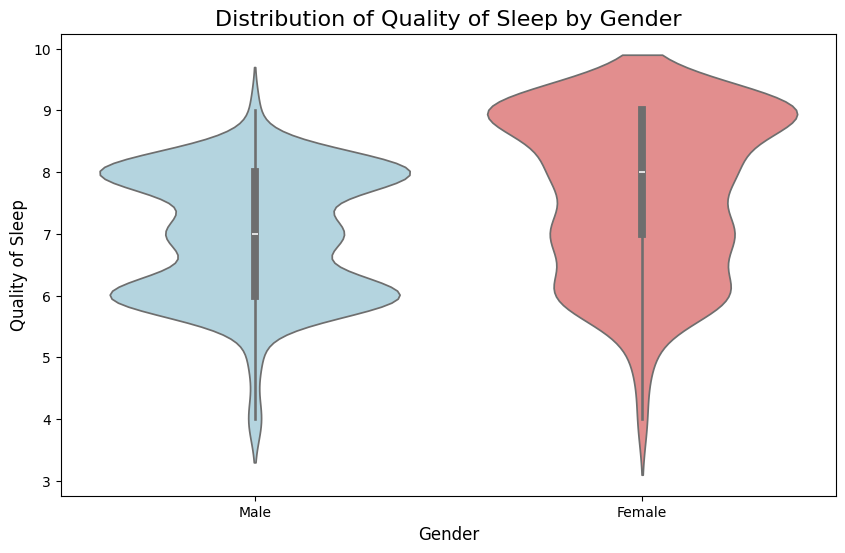

In [ ]:
color_palette = {'Male': 'lightblue', 'Female': 'lightcoral'}
plt.figure(figsize=(10, 6))
sns.violinplot(x='Gender', y='Quality of Sleep', data=df, palette=color_palette)
plt.title('Distribution of Quality of Sleep by Gender', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Quality of Sleep', fontsize=12)
plt.show()

In [ ]:
fig = px.bar(df,
             x='Stress Level',
             y='Quality of Sleep',
             color='Stress Level',
             title='Relationship between Stress Level and Quality of Sleep'
            )
fig.show()

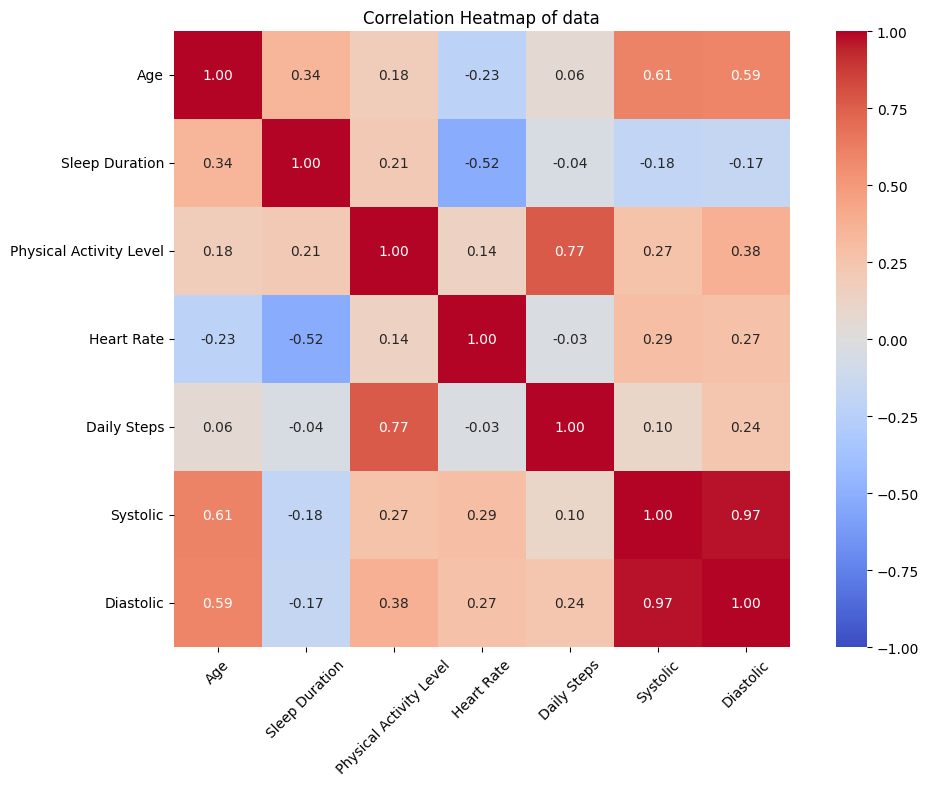

In [ ]:
df = pd.concat([df, df['Blood Pressure'].str.split('/', expand=True)], axis=1).drop('Blood Pressure', axis=1)
df = df.rename(columns={0: 'Systolic', 1: 'Diastolic'})
df['Systolic'] = df['Systolic'].astype(float)
df['Diastolic'] = df['Diastolic'].astype(float)
numeric_features = ['Age', 'Sleep Duration',
                    'Physical Activity Level',
                    'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(12, 8))


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)


plt.title('Correlation Heatmap of data')
plt.xticks(rotation=45)
plt.yticks(rotation=0)


plt.show()

In [ ]:
df.drop(columns=['Person ID'],inplace = True)
label_encoder = LabelEncoder()
df['Sleep Disorder'] = label_encoder.fit_transform(df['Sleep Disorder'])
print(label_encoder.classes_)

['Insomnia' 'No Disorder' 'Sleep Apnea']


In [ ]:
numeric_features = ['Age', 'Sleep Duration',
                    'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']

categorical_features = ['Occupation','Quality of Sleep','Gender',
                    'Physical Activity Level', 'Stress Level', 'BMI Category']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first',sparse_output =False, handle_unknown='ignore'), categorical_features)
    ])
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']
X_preprocessed = preprocessor.fit_transform(X)

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_preprocessed, y)
X_smote.shape

(657, 44)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.25, random_state=42)

Accuracy: 0.9090909090909091
Precision: 0.910767756617559
Recall: 0.9090909090909091
F1-score: 0.9084234273263183
              precision    recall  f1-score   support

           0       0.94      0.82      0.87        38
           1       0.88      0.95      0.92        64
           2       0.92      0.92      0.92        63

    accuracy                           0.91       165
   macro avg       0.91      0.90      0.90       165
weighted avg       0.91      0.91      0.91       165

Confusion Matrix:
[[31  3  4]
 [ 2 61  1]
 [ 0  5 58]]


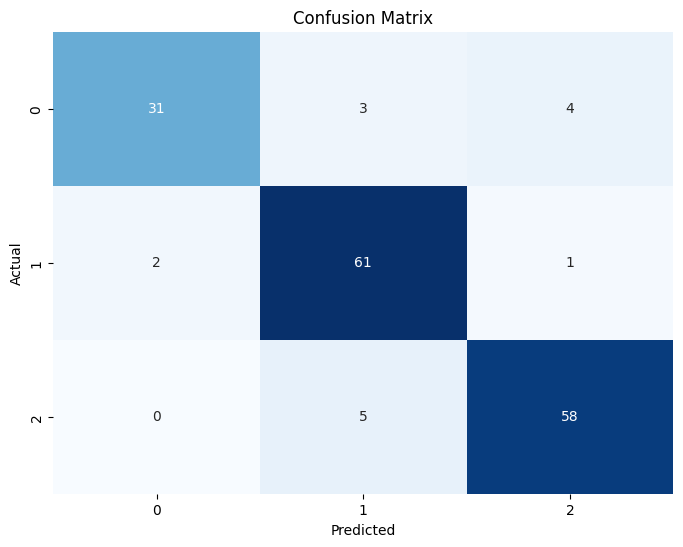

In [ ]:
# Initialize Logistic Regression classifier
model_lr = LogisticRegression()

# Fit the model on the training data
model_lr.fit(X_train, y_train)


y_pred_lr = model_lr.predict(X_test)


accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')


print(f'Accuracy: {accuracy_lr}')
print(f'Precision: {precision_lr}')
print(f'Recall: {recall_lr}')
print(f'F1-score: {f1_lr}')


print(classification_report(y_test, y_pred_lr))


cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Confusion Matrix:')
print(cm_lr)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Accuracy: 0.9272727272727272
Precision: 0.9287307861220904
Recall: 0.9272727272727272
F1-score: 0.9271254483064495
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        38
           1       0.90      0.97      0.93        64
           2       0.97      0.92      0.94        63

    accuracy                           0.93       165
   macro avg       0.93      0.92      0.92       165
weighted avg       0.93      0.93      0.93       165

Confusion Matrix:
[[33  3  2]
 [ 2 62  0]
 [ 1  4 58]]


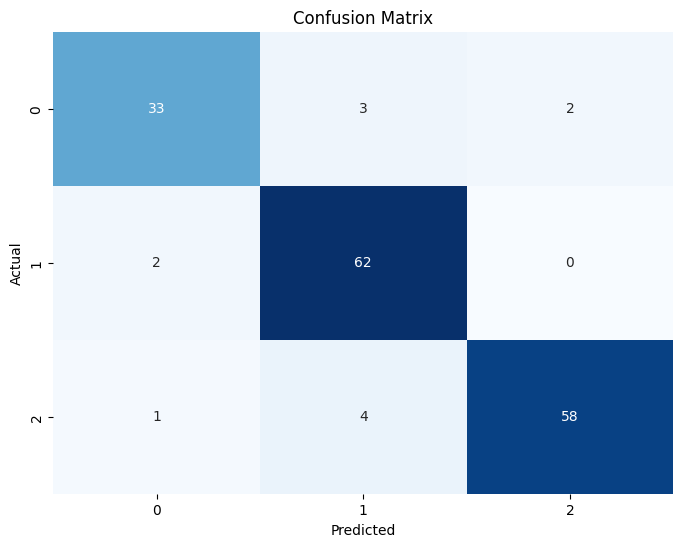

In [ ]:

model_xgb = xgb.XGBClassifier()


model_xgb.fit(X_train, y_train)


y_pred = model_xgb.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred)
precision_xgb = precision_score(y_test, y_pred, average='weighted')
recall_xgb = recall_score(y_test, y_pred, average='weighted')
f1_xgb = f1_score(y_test, y_pred, average='weighted')


print(f'Accuracy: {accuracy_xgb}')
print(f'Precision: {precision_xgb}')
print(f'Recall: {recall_xgb}')
print(f'F1-score: {f1_xgb}')

print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scores = cross_val_score(xgb_model, X_smote, y_smote, cv=cv, scoring='accuracy')
scores

array([0.92424242, 0.89393939, 0.92366412, 0.9389313 , 0.92366412])

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86        38
           1       0.90      0.97      0.93        64
           2       0.95      0.90      0.93        63

    accuracy                           0.92       165
   macro avg       0.91      0.91      0.91       165
weighted avg       0.92      0.92      0.91       165



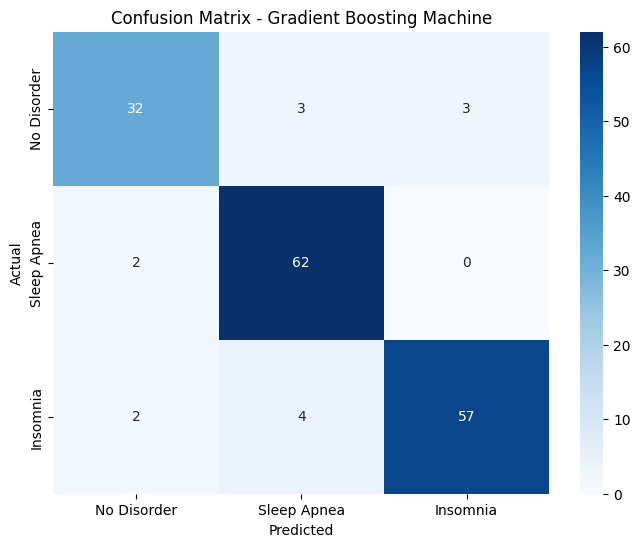

Accuracy: 0.9152
Precision: 0.9160
Recall: 0.9152
F1 Score: 0.9147


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier


gbm_clf = GradientBoostingClassifier(random_state=42)


gbm_clf.fit(X_train, y_train)


y_pred = gbm_clf.predict(X_test)


accuracy_gbm = accuracy_score(y_test, y_pred)
precision_gbm = precision_score(y_test, y_pred, average='weighted')
recall_gbm = recall_score(y_test, y_pred, average='weighted')
f1_gbm = f1_score(y_test, y_pred, average='weighted')


print("Classification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['No Disorder', 'Sleep Apnea', 'Insomnia'], yticklabels=['No Disorder', 'Sleep Apnea', 'Insomnia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting Machine')
plt.show()

print(f"Accuracy: {accuracy_gbm:.4f}")
print(f"Precision: {precision_gbm:.4f}")
print(f"Recall: {recall_gbm:.4f}")
print(f"F1 Score: {f1_gbm:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        38
           1       0.91      0.91      0.91        64
           2       0.97      0.92      0.94        63

    accuracy                           0.91       165
   macro avg       0.90      0.91      0.90       165
weighted avg       0.91      0.91      0.91       165



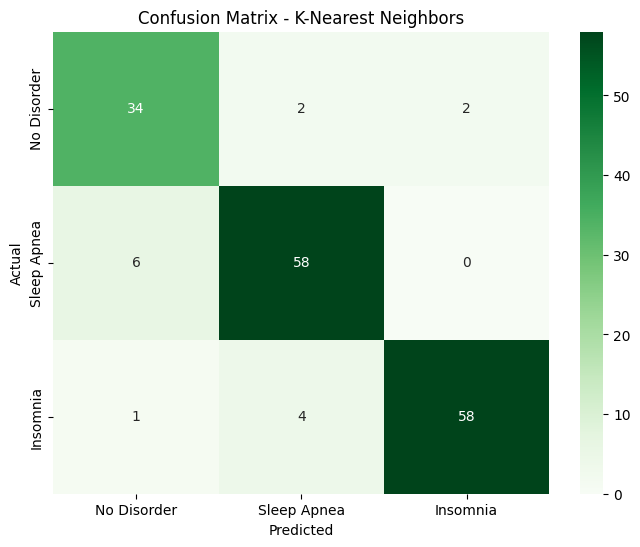

Accuracy: 0.9091
Precision: 0.9116
Recall: 0.9091
F1 Score: 0.9098


In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn_clf = KNeighborsClassifier(n_neighbors=5)


knn_clf.fit(X_train, y_train)


y_pred = knn_clf.predict(X_test)


accuracy_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, average='weighted')
recall_knn = recall_score(y_test, y_pred, average='weighted')
f1_knn = f1_score(y_test, y_pred, average='weighted')


print("Classification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='d', xticklabels=['No Disorder', 'Sleep Apnea', 'Insomnia'], yticklabels=['No Disorder', 'Sleep Apnea', 'Insomnia'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.show()


print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")

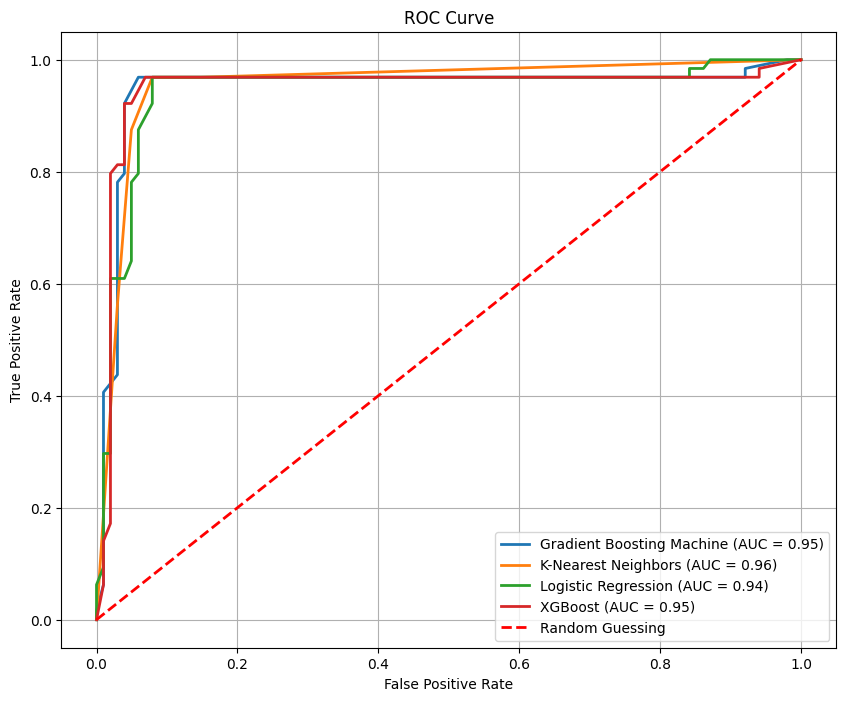

In [ ]:
from sklearn.metrics import roc_curve, auc


fig_roc = plt.figure(figsize=(10, 8))
models = ['Gradient Boosting Machine', 'K-Nearest Neighbors', 'Logistic Regression', 'XGBoost']


for idx, model in enumerate([gbm_clf, knn_clf, model_lr, model_xgb]):
    if model == knn_clf:
        y_scores = model.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_scores[:, 1], pos_label=1)
    else:
        y_scores = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=1)

    roc_auc = auc(fpr, tpr)


    plt.plot(fpr, tpr, lw=2, label=f'{models[idx]} (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Random Guessing')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()


plt.show()

In [ ]:
print(model_xgb)
print(preprocessor)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
ColumnTransformer(transformers=[('num', RobustScaler(),
                                 ['Age', 'Sleep Duration', 'Heart Rate',
                                  'Daily Steps', 'Systolic', 'Diastolic']),
                                ('c

In [ ]:
print(X.columns.tolist())

['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic']


In [ ]:
print(sorted(df["Occupation"].unique()))

print(sorted(df["BMI Category"].unique()))

print(sorted(df["Gender"].unique()))

print(sorted(df["Quality of Sleep"].unique()))

print(sorted(df["Physical Activity Level"].unique()))

print(sorted(df["Stress Level"].unique()))

['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse', 'Sales Representative', 'Salesperson', 'Scientist', 'Software Engineer', 'Teacher']
['Normal Weight', 'Obese', 'Overweight']
['Female', 'Male']
[np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
[np.int64(30), np.int64(32), np.int64(35), np.int64(40), np.int64(42), np.int64(45), np.int64(47), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90)]
[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [ ]:
occupations = sorted(df["Occupation"].unique())
genders = sorted(df["Gender"].unique())
bmi_categories = sorted(df["BMI Category"].unique())

In [ ]:

import pandas as pd

def choose_option(options, title):
    print(f"\n{title}")
    print("-" * len(title))

    for i, option in enumerate(options, start=1):
        print(f"{i}. {option}")

    while True:
        try:
            choice = int(input("\nEnter your choice: "))
            if 1 <= choice <= len(options):
                return options[choice - 1]
            else:
                print("❌ Invalid choice. Try again.")
        except:
            print("❌ Please enter a valid number.")

def get_int(prompt, min_value, max_value):
    while True:
        try:
            value = int(input(prompt))
            if min_value <= value <= max_value:
                return value
            else:
                print(f"❌ Enter a value between {min_value} and {max_value}")
        except:
            print("❌ Please enter a valid integer.")

def get_float(prompt, min_value, max_value):
    while True:
        try:
            value = float(input(prompt))
            if min_value <= value <= max_value:
                return value
            else:
                print(f"❌ Enter a value between {min_value} and {max_value}")
        except:
            print("❌ Please enter a valid number.")

print("="*65)
print("          SLEEP DISORDER PREDICTION SYSTEM")
print("="*65)

gender = choose_option(genders,"Select Gender")
occupation = choose_option(occupations,"Select Occupation")
bmi = choose_option(bmi_categories,"Select BMI Category")

age = get_int("\nAge (18-80): ",18,80)

sleep_duration = get_float("Sleep Duration (3-12 hrs): ",3,12)

quality_sleep = get_int("Quality of Sleep (4-9): ",4,9)

physical_activity = get_int("Physical Activity Level (30-90 mins): ",30,90)

stress_level = get_int("Stress Level (3-8): ",3,8)

heart_rate = get_int("Heart Rate (40-120 bpm): ",40,120)

daily_steps = get_int("Daily Steps (500-30000): ",500,30000)

systolic = get_int("Systolic BP (80-220): ",80,220)

diastolic = get_int("Diastolic BP (50-140): ",50,140)

          SLEEP DISORDER PREDICTION SYSTEM

Select Gender
-------------
1. Female
2. Male

Enter your choice: 2

Select Occupation
-----------------
1. Accountant
2. Doctor
3. Engineer
4. Lawyer
5. Manager
6. Nurse
7. Sales Representative
8. Salesperson
9. Scientist
10. Software Engineer
11. Teacher

Enter your choice: 3

Select BMI Category
-------------------
1. Normal Weight
2. Obese
3. Overweight

Enter your choice: 2

Age (18-80): 18
Sleep Duration (3-12 hrs): 3
Quality of Sleep (4-9): 4
Physical Activity Level (30-90 mins): 90
Stress Level (3-8): 3
Heart Rate (40-120 bpm): 40
Daily Steps (500-30000): 500
Systolic BP (80-220): 220
Diastolic BP (50-140): 50


In [ ]:
user_data = pd.DataFrame({
    "Gender":[gender],
    "Age":[age],
    "Occupation":[occupation],
    "Sleep Duration":[sleep_duration],
    "Quality of Sleep":[quality_sleep],
    "Physical Activity Level":[physical_activity],
    "Stress Level":[stress_level],
    "BMI Category":[bmi],
    "Heart Rate":[heart_rate],
    "Daily Steps":[daily_steps],
    "Systolic":[systolic],
    "Diastolic":[diastolic]
})

print("\nUser Details")
print(user_data)


User Details
  Gender  Age Occupation  Sleep Duration  Quality of Sleep  \
0   Male   18   Engineer             3.0                 4   

   Physical Activity Level  Stress Level BMI Category  Heart Rate  \
0                       90             3        Obese          40   

   Daily Steps  Systolic  Diastolic  
0          500       220         50  


In [ ]:
user_processed = preprocessor.transform(user_data)

prediction = model_xgb.predict(user_processed)

probability = model_xgb.predict_proba(user_processed)

labels={
    0:"Insomnia",
    1:"No Disorder",
    2:"Sleep Apnea"
}

predicted=labels[prediction[0]]

confidence=max(probability[0])*100

In [ ]:
print("\n"+"="*65)
print("                 PREDICTION RESULT")
print("="*65)

print(f"Predicted Sleep Disorder : {predicted}")
print(f"Prediction Confidence    : {confidence:.2f}%")

print("\nPrediction Probabilities")
print("-"*30)

for i,label in labels.items():
    print(f"{label:<15}: {probability[0][i]*100:.2f}%")


                 PREDICTION RESULT
Predicted Sleep Disorder : Insomnia
Prediction Confidence    : 82.84%

Prediction Probabilities
------------------------------
Insomnia       : 82.84%
No Disorder    : 14.92%
Sleep Apnea    : 2.23%


In [ ]:
print("\n" + "="*70)
print("                 USER INPUT SUMMARY")
print("="*70)

print(f"Gender                    : {gender}")
print(f"Age                       : {age}")
print(f"Occupation                : {occupation}")
print(f"Sleep Duration            : {sleep_duration} Hours")
print(f"Quality of Sleep          : {quality_sleep}/9")
print(f"Physical Activity Level   : {physical_activity} Minutes")
print(f"Stress Level              : {stress_level}/8")
print(f"BMI Category              : {bmi}")
print(f"Heart Rate                : {heart_rate} bpm")
print(f"Daily Steps               : {daily_steps}")
print(f"Blood Pressure            : {systolic}/{diastolic}")


                 USER INPUT SUMMARY
Gender                    : Male
Age                       : 18
Occupation                : Engineer
Sleep Duration            : 3.0 Hours
Quality of Sleep          : 4/9
Physical Activity Level   : 90 Minutes
Stress Level              : 3/8
BMI Category              : Obese
Heart Rate                : 40 bpm
Daily Steps               : 500
Blood Pressure            : 220/50


In [ ]:
print("\n" + "="*70)
print("              SLEEP DISORDER PREDICTION REPORT")
print("="*70)

print(f"Predicted Sleep Disorder : {predicted}")
print(f"Prediction Confidence    : {confidence:.2f}%")


              SLEEP DISORDER PREDICTION REPORT
Predicted Sleep Disorder : Insomnia
Prediction Confidence    : 82.84%


In [ ]:
print("\n" + "="*70)
print("                PREDICTION PROBABILITIES")
print("="*70)

print(f"{'Sleep Disorder':<25}{'Probability':>15}")
print("-"*70)

for i, label in labels.items():
    print(f"{label:<25}{probability[0][i]*100:>13.2f}%")


                PREDICTION PROBABILITIES
Sleep Disorder               Probability
----------------------------------------------------------------------
Insomnia                         82.84%
No Disorder                      14.92%
Sleep Apnea                       2.23%


In [ ]:
print("\n" + "="*70)
print("               PREDICTION RELIABILITY")
print("="*70)

if confidence >= 90:
    reliability = "Very High"
    message = "The model is highly confident in this prediction."

elif confidence >= 75:
    reliability = "High"
    message = "The model is confident in this prediction."

elif confidence >= 60:
    reliability = "Moderate"
    message = "The prediction is reasonably reliable."

else:
    reliability = "Low"
    message = "The prediction is uncertain because multiple classes have similar probabilities."

print(f"Reliability Level : {reliability}")
print(f"Explanation        : {message}")


               PREDICTION RELIABILITY
Reliability Level : High
Explanation        : The model is confident in this prediction.


In [ ]:
print("\n" + "="*70)
print("                 HEALTH RECOMMENDATIONS")
print("="*70)

if predicted == "No Disorder":

    print("Overall Assessment : Healthy Sleep Pattern")
    print("\nRecommendations:")
    print("✔ Continue maintaining a regular sleep schedule.")
    print("✔ Exercise regularly.")
    print("✔ Maintain a balanced diet.")
    print("✔ Stay hydrated.")
    print("✔ Aim for 7-9 hours of sleep daily.")

elif predicted == "Insomnia":

    print("Overall Assessment : Possible Signs of Insomnia")
    print("\nRecommendations:")
    print("✔ Maintain a consistent bedtime.")
    print("✔ Avoid caffeine and nicotine in the evening.")
    print("✔ Reduce screen time before sleeping.")
    print("✔ Practice relaxation techniques such as meditation.")
    print("✔ Consult a healthcare professional if symptoms continue.")

elif predicted == "Sleep Apnea":

    print("Overall Assessment : Possible Signs of Sleep Apnea")
    print("\nRecommendations:")
    print("✔ Consult a sleep specialist.")
    print("✔ Maintain a healthy body weight.")
    print("✔ Avoid alcohol before bedtime.")
    print("✔ Sleep on your side if advised.")
    print("✔ Consider a professional sleep study.")

print("\nNote:")
print("This prediction is generated using a Machine Learning model.")
print("It is intended for educational purposes only and should not")
print("replace professional medical advice or diagnosis.")


                 HEALTH RECOMMENDATIONS
Overall Assessment : Possible Signs of Insomnia

Recommendations:
✔ Maintain a consistent bedtime.
✔ Avoid caffeine and nicotine in the evening.
✔ Reduce screen time before sleeping.
✔ Practice relaxation techniques such as meditation.
✔ Consult a healthcare professional if symptoms continue.

Note:
This prediction is generated using a Machine Learning model.
It is intended for educational purposes only and should not
replace professional medical advice or diagnosis.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importances from XGBoost
importance = model_xgb.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort descending
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 15 Features
print(importance_df.head(15))

                                 Feature  Importance
43          cat__BMI Category_Overweight    0.379787
26       cat__Physical Activity Level_45    0.320981
31       cat__Physical Activity Level_65    0.093370
4                          num__Systolic    0.055491
2                        num__Heart Rate    0.017645
16               cat__Quality of Sleep_5    0.015844
40                   cat__Stress Level_7    0.013832
33       cat__Physical Activity Level_75    0.011918
38                   cat__Stress Level_5    0.011721
7               cat__Occupation_Engineer    0.010646
11  cat__Occupation_Sales Representative    0.010298
14     cat__Occupation_Software Engineer    0.008077
36       cat__Physical Activity Level_90    0.005130
39                   cat__Stress Level_6    0.004629
18               cat__Quality of Sleep_7    0.003929


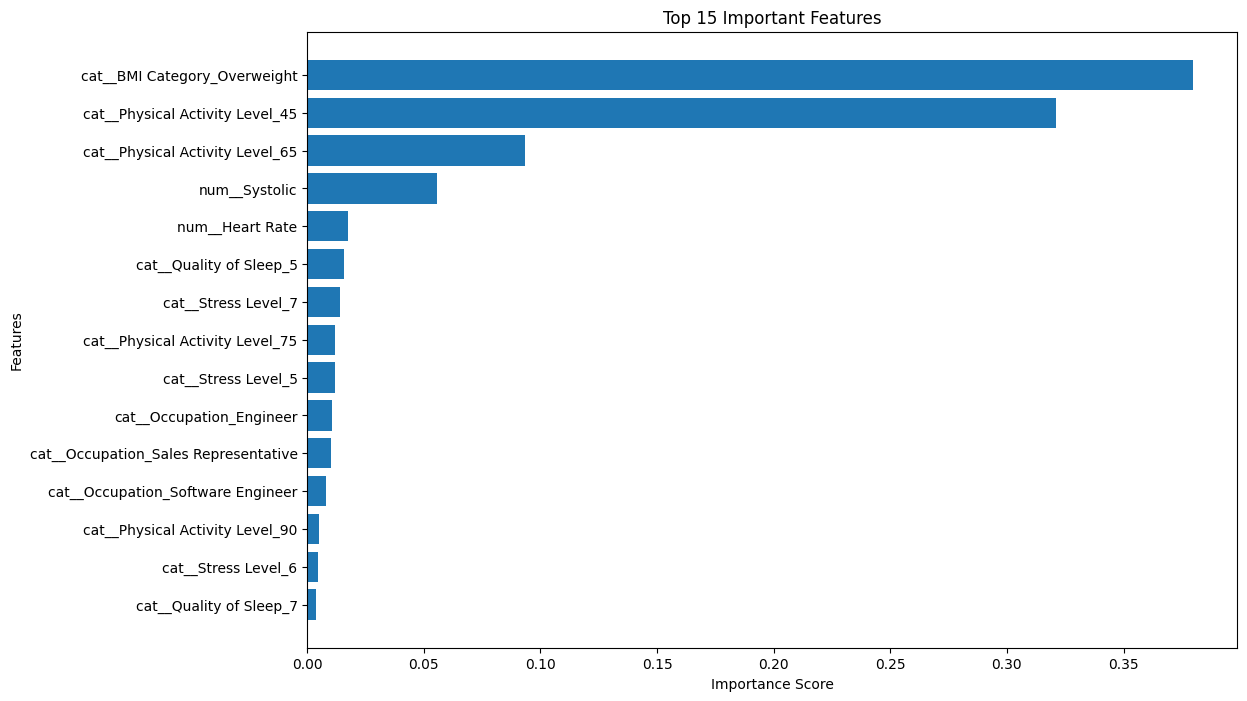

In [ ]:
plt.figure(figsize=(12,8))

top15 = importance_df.head(15)

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.show()

In [ ]:
import pickle

# Save trained XGBoost model
with open("Model_Prediction.sav", "wb") as f:
    pickle.dump(model_xgb, f)

# Save fitted preprocessor
with open("preprocessor.sav", "wb") as f:
    pickle.dump(preprocessor, f)

print("✅ Model and Preprocessor saved successfully.")

✅ Model and Preprocessor saved successfully.


In [ ]:
import os

print(os.listdir())

['.config', '.gradio', 'preprocessor.sav', 'Sleep_health_and_lifestyle_dataset.csv', 'Model_Prediction.sav', 'Sleep_health .csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("Model_Prediction.sav")
files.download("preprocessor.sav")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir())

['.config', '.gradio', 'preprocessor.sav', 'Sleep_health_and_lifestyle_dataset.csv', 'Model_Prediction.sav', 'Sleep_health .csv', 'sample_data']


In [ ]:
!pip install gradio


In [ ]:
import joblib

model = joblib.load("Model_Prediction.sav")
preprocessor = joblib.load("preprocessor.sav")

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import gradio as gr
import pandas as pd

labels = {
    0: "Insomnia",
    1: "No Disorder",
    2: "Sleep Apnea"
}

def predict_sleep_disorder(
    gender,
    age,
    occupation,
    sleep_duration,
    quality_sleep,
    physical_activity,
    stress_level,
    bmi,
    heart_rate,
    daily_steps,
    systolic,
    diastolic
):

    user_data = pd.DataFrame({
        "Gender": [gender],
        "Age": [age],
        "Occupation": [occupation],
        "Sleep Duration": [sleep_duration],
        "Quality of Sleep": [quality_sleep],
        "Physical Activity Level": [physical_activity],
        "Stress Level": [stress_level],
        "BMI Category": [bmi],
        "Heart Rate": [heart_rate],
        "Daily Steps": [daily_steps],
        "Systolic": [systolic],
        "Diastolic": [diastolic]
    })

    user_processed = preprocessor.transform(user_data)

    prediction = model.predict(user_processed)

    probability = model.predict_proba(user_processed)

    predicted = labels[prediction[0]]

    confidence = max(probability[0]) * 100

    result = f"""
    Prediction Result
    -----------------------
    Sleep Disorder : {predicted}
    Confidence     : {confidence:.2f}%

    Probability:
    Insomnia       : {probability[0][0]*100:.2f}%
    No Disorder    : {probability[0][1]*100:.2f}%
    Sleep Apnea    : {probability[0][2]*100:.2f}%
    """

    return result

In [ ]:
occupation_choices = sorted(df["Occupation"].unique())
gender_choices = sorted(df["Gender"].unique())
bmi_choices = sorted(df["BMI Category"].unique())


interface = gr.Interface(
    fn=predict_sleep_disorder,

    inputs=[
        gr.Dropdown(gender_choices, label="Gender"),
        gr.Slider(18, 80, value=30, label="Age"),
        gr.Dropdown(occupation_choices, label="Occupation"),
        gr.Slider(3, 12, value=7, label="Sleep Duration (Hours)"),
        gr.Slider(4, 9, value=7, step=1, label="Quality of Sleep"),
        gr.Slider(30, 90, value=60, step=1, label="Physical Activity Level"),
        gr.Slider(3, 8, value=5, step=1, label="Stress Level"),
        gr.Dropdown(bmi_choices, label="BMI Category"),
        gr.Slider(40, 120, value=70, step=1, label="Heart Rate"),
        gr.Slider(500, 30000, value=7000, step=100, label="Daily Steps"),
        gr.Slider(80, 220, value=120, step=1, label="Systolic Blood Pressure"),
        gr.Slider(50, 140, value=80, step=1, label="Diastolic Blood Pressure")
    ],

    outputs=gr.Textbox(
        label="Sleep Disorder Prediction Report",
        lines=12
    ),

    title="😴 Sleep Disorder Prediction System",
    description="Machine Learning based prediction of Sleep Disorders using lifestyle and health parameters."
)


interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5cee41721b23968329.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
